In [1]:
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
import nltk
from IPython.display import display
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Download NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

df = pd.read_csv('simple_dataset.csv')

Matplotlib is building the font cache; this may take a moment.
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /home/d754b29c-508d-4bde-938d-
[nltk_data]     34c5de7c5059/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [2]:
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_review(review):
    review = review.lower()
    review = re.sub(r'[^\w\s]', '', review)
    review = re.sub(r'\d+', '', review)

    tokens = word_tokenize(review)

    stop_words = set(stopwords.words('english'))
    tokens = [word for word in tokens if word not in stop_words]

    stemmed_tokens = [stemmer.stem(word) for word in tokens]
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens]

    preprocessed_review = ' '.join(lemmatized_tokens)

    return preprocessed_review

In [3]:
df['preprocessed_text'] = df['text'].apply(preprocess_review)
display(df)

,category,text,preprocessed_text
0,Positive,I love this product! It works great and has ex...,love product work great excellent quality
1,Negative,Terrible experience. The product broke after o...,terrible experience product broke one use
2,Positive,Fantastic! I would highly recommend this to ev...,fantastic would highly recommend everyone
3,Negative,Awful. It was a complete waste of money.,awful complete waste money
4,Positive,Amazing product! Very satisfied with my purchase.,amazing product satisfied purchase
5,Negative,Do not buy this. It is not worth the price.,buy worth price


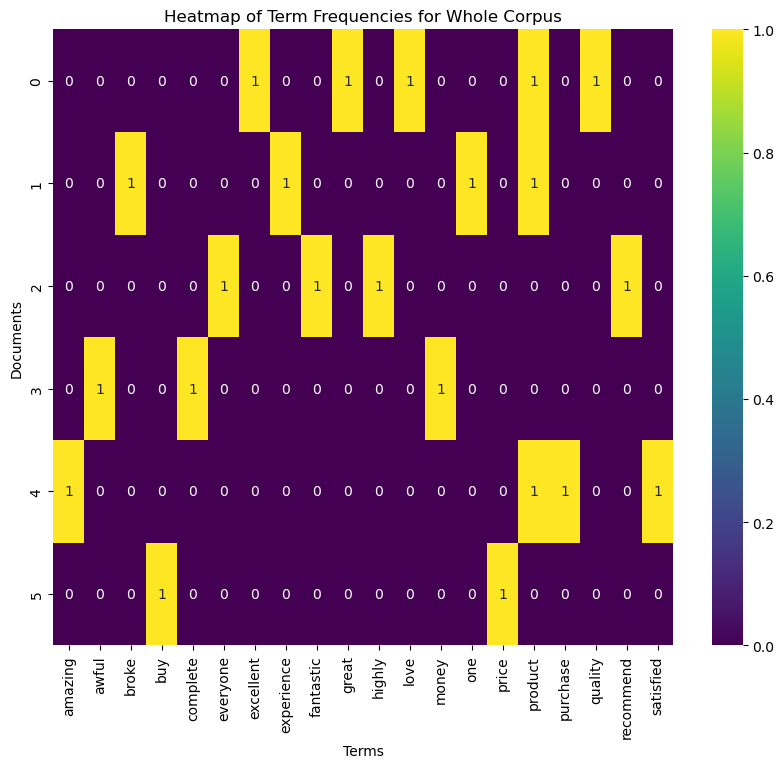

In [4]:
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])

term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, cmap='viridis', annot=True)
plt.title("Heatmap of Term Frequencies for Whole Corpus")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

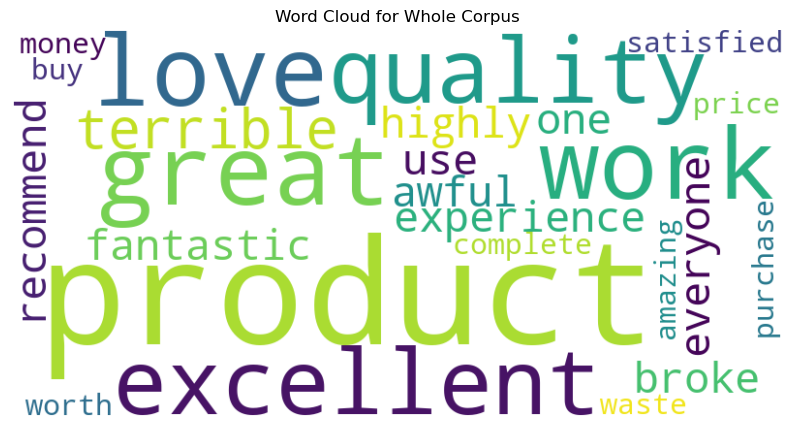

In [5]:
all_text = " ".join(df['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()

In [6]:
positive_text = ' '.join(df[df['category'] == 'Positive']['preprocessed_text'])
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

negative_text = ' '.join(df[df['category'] == 'Negative']['preprocessed_text'])
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

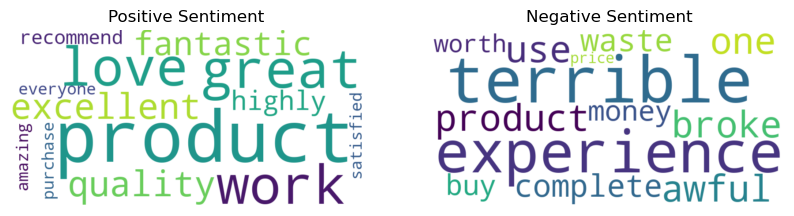

In [7]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')

plt.show()

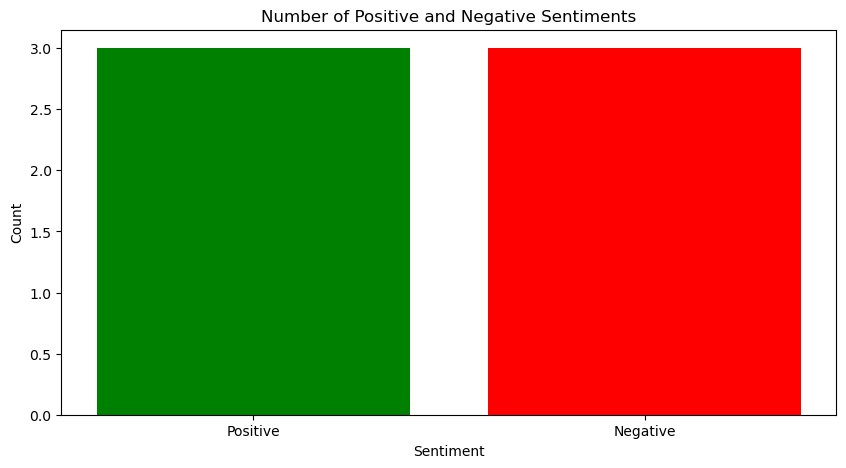

In [8]:
sentiment_counts = df['category'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red'])

plt.title('Number of Positive and Negative Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

**Real Dataset**

In [9]:
df = pd.read_csv('restaurant_reviews.csv')

In [10]:
df['preprocessed_text'] = df['Review'].apply(preprocess_review)
display(df)

,Review,Sentiment,Category,Topics,preprocessed_text
0,I love the cozy atmosphere of this place. The ...,Positive,Dining Experience,"atmosphere, pizza, staff",love cozy atmosphere place pizza delicious sta...
1,The sushi at this place was terrible. It was b...,Negative,Food,sushi,sushi place terrible bland poorly cooked wont ...
2,I love the cozy atmosphere of this place. The ...,Positive,Dining Experience,"atmosphere, pasta, staff",love cozy atmosphere place pasta delicious sta...
3,The salad at this place was decent. Nothing ex...,Neutral,Food,salad,salad place decent nothing exceptional nothing...
4,This hotel was alright. The sushi was nothing ...,Neutral,Dining Experience,sushi,hotel alright sushi nothing special wasnt bad ...
5,I can't say enough good things about this hote...,Positive,Dining Experience,"pasta, service",cant say enough good thing hotel pasta exceede...
6,The food at this restaurant was amazing! I had...,Positive,Dining Experience,"steak, service",food restaurant amazing steak cooked perfectio...
7,This hotel was alright. The burger was nothing...,Neutral,Dining Experience,burger,hotel alright burger nothing special wasnt bad...
8,I had an okay experience at this hotel. The su...,Neutral,Dining Experience,"sushi, service",okay experience hotel sushi average service ad...
9,The pizza at this place was decent. Nothing ex...,Neutral,Food,pizza,pizza place decent nothing exceptional nothing...


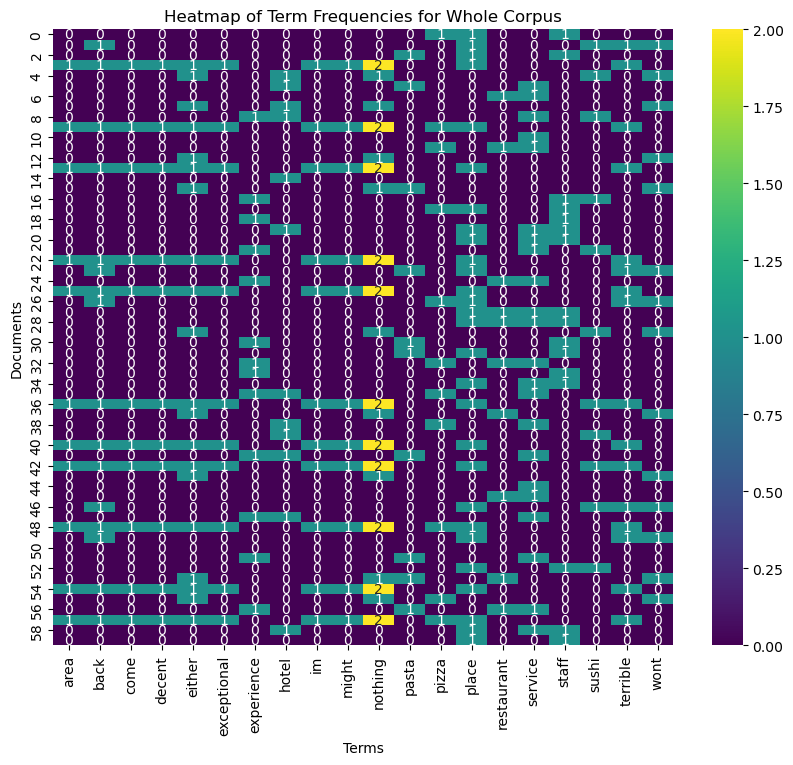

In [11]:
vectorizer = CountVectorizer(max_features=20)
X = vectorizer.fit_transform(df['preprocessed_text'])

term_freq_matrix = X.toarray()
terms = vectorizer.get_feature_names_out()

plt.figure(figsize=(10, 8))
sns.heatmap(term_freq_matrix, xticklabels=terms, cmap='viridis', annot=True)

plt.title("Heatmap of Term Frequencies for Whole Corpus")
plt.xlabel("Terms")
plt.ylabel("Documents")
plt.show()

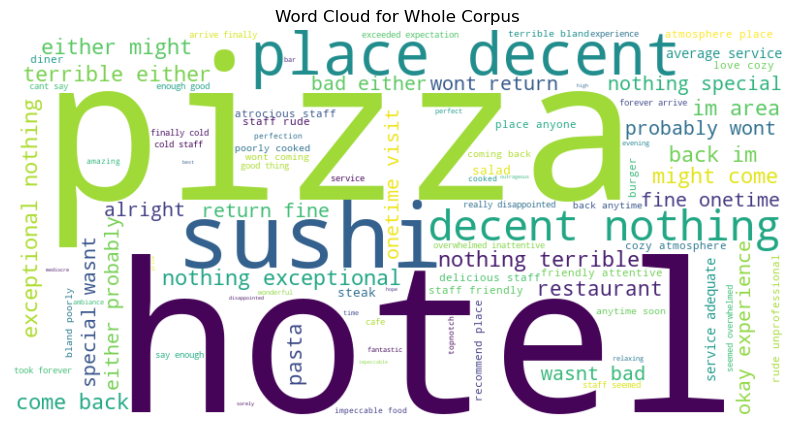

In [12]:
all_text = " ".join(df['preprocessed_text'])

wordcloud = WordCloud(width=800, height=400, max_words=100, background_color='white').generate(all_text)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud for Whole Corpus")
plt.show()

In [13]:
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['preprocessed_text'])
positive_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)

negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['preprocessed_text'])
negative_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

neutral_text = ' '.join(df[df['Sentiment'] == 'Neutral']['preprocessed_text'])
neutral_wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neutral_text)

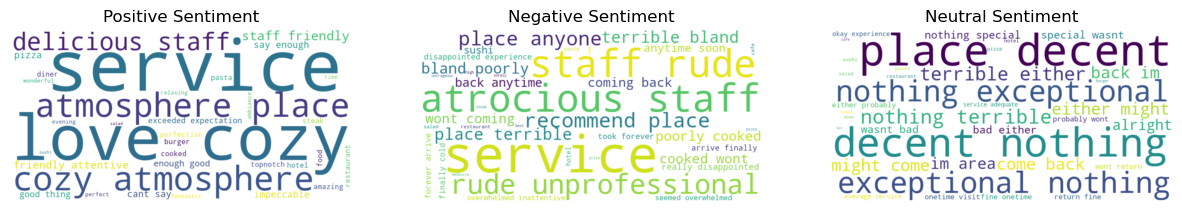

In [14]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(positive_wordcloud, interpolation='bilinear')
plt.title('Positive Sentiment')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(negative_wordcloud, interpolation='bilinear')
plt.title('Negative Sentiment')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(neutral_wordcloud, interpolation='bilinear')
plt.title('Neutral Sentiment')
plt.axis('off')

plt.show()

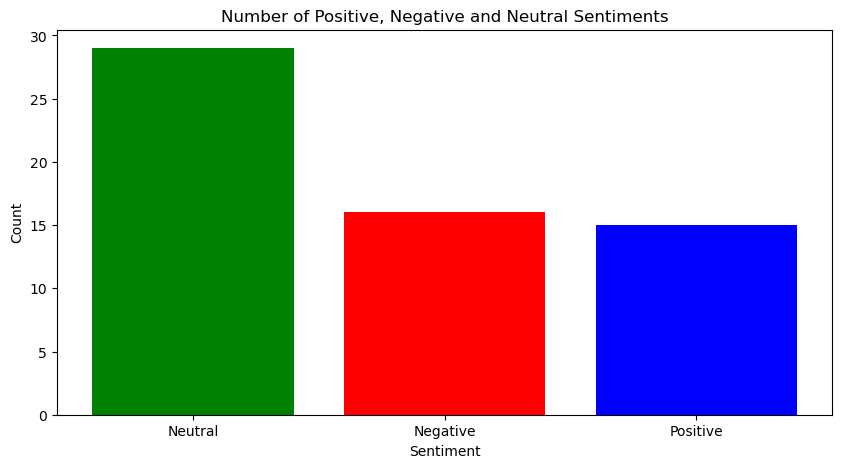

In [15]:
sentiment_counts = df['Sentiment'].value_counts()

plt.figure(figsize=(10, 5))
plt.bar(sentiment_counts.index, sentiment_counts.values, color=['green', 'red', 'blue'])

plt.title('Number of Positive, Negative and Neutral Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

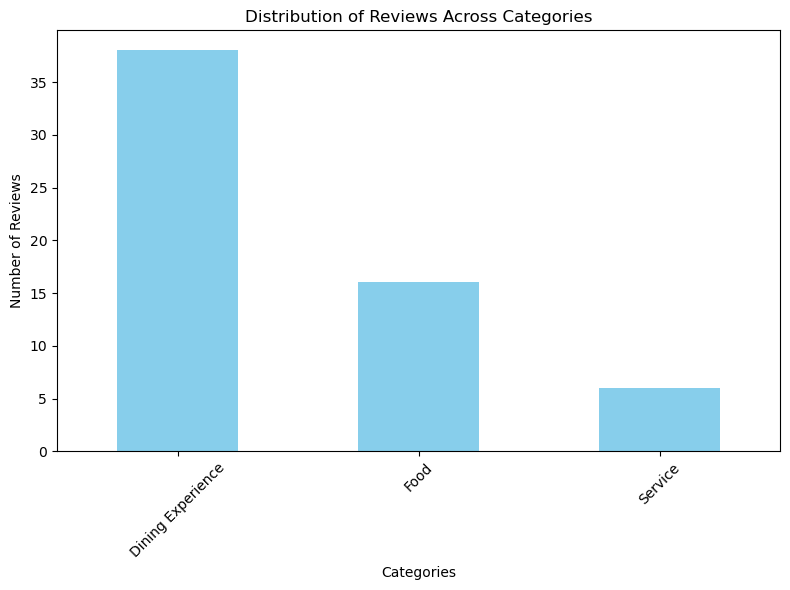

In [16]:
category_counts = df['Category'].value_counts()

plt.figure(figsize=(8, 6))
category_counts.plot(kind='bar', color='skyblue')

plt.xlabel('Categories')
plt.ylabel('Number of Reviews')
plt.title('Distribution of Reviews Across Categories')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

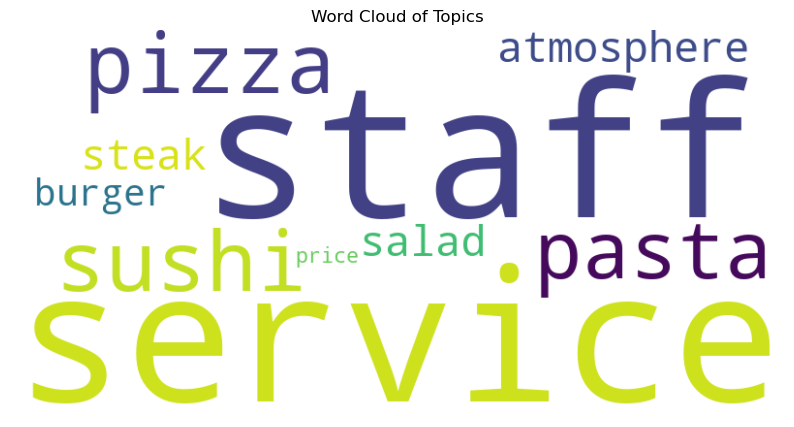

In [17]:
from collections import Counter

all_topics = [topic for topics in df['Topics'].str.split(', ') for topic in topics]
topic_counts = Counter(all_topics)

wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(topic_counts)

plt.figure(figsize=(10, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Topics')
plt.show()